In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Load the graph
import networkx as nx
G = nx.read_gml('../data/graph/LEMD_EGLL_2023_04_01.gml')
# Load node ID mappings
node_list = list(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

In [3]:
# Shortest path from LEMD to EGLL
shortest_path = nx.shortest_path(G, source='LEMD', target='EGLL')
print(shortest_path)

['LEMD', 'LETP', 'KOVAK', 'EGLL']


In [4]:
# Load the forward value functions
import numpy as np
V_final_fw = np.load('../data/results/forward/V_final.npy')
eta_final_fw = np.load('../data/results/forward/eta_final.npy')
alt_final_fw = np.load('../data/results/forward/alt_final.npy')
phase_final_fw = np.load('../data/results/forward/phase_final.npy')
V_final_margin_fw = np.array([np.sum(row[np.isfinite(row)]) for row in V_final_fw])

# Load the backward value functions
V_final_bw = np.load('../data/results/backward/V_final_bw.npy')
eta_final_bw = np.load('../data/results/backward/eta_final_bw.npy')
alt_final_bw = np.load('../data/results/backward/alt_final_bw.npy')
phase_final_bw = np.load('../data/results/backward/phase_final_bw.npy')
V_final_margin_bw = np.array([np.sum(row[np.isfinite(row)]) for row in V_final_bw])

# Inspection

In [5]:
V_final_bw[node_to_idx['LFDA']]

array([        inf,         inf,         inf,         inf, -2.28163294,
       -2.31288532, -2.20282078, -2.18121419, -2.44614462, -2.45866608,
       -2.39880246, -2.48053603, -2.42002329, -2.3143121 , -2.46993218,
       -2.40415965, -2.42110545, -2.44838162, -2.39062815, -2.33114265,
       -2.27457991, -2.26070904, -2.19656546, -2.19120703,         inf,
               inf,         inf,         inf,         inf,         inf,
               inf])

In [6]:
V_final_bw[node_to_idx['LETP']]

array([-3.32972821, -3.27843976, -3.37029441, -3.3598951 , -3.37942418,
       -3.38192062, -3.30459402, -3.41074373, -3.37008519, -3.34900991,
       -3.37242001, -3.33307406, -3.32270283, -3.26760312, -3.28582398,
       -3.3038363 , -3.14011697, -3.12754493, -3.1262195 , -3.10349214,
       -2.96531479, -2.79120466,         inf,         inf,         inf,
               inf,         inf,         inf,         inf,         inf,
               inf])

In [7]:
V_final_bw[node_to_idx['EGLL']]

array([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
       inf, inf, inf, inf,  0.])

In [8]:
print(V_final_bw[node_to_idx['LEMD']])
print(eta_final_bw[node_to_idx['LEMD']])

[-3.58414901 -3.5991419  -3.57433638 -3.63484411 -3.62304321 -3.61605696
 -3.6321405  -3.61088805 -3.56361085 -3.59342009 -3.54511559 -3.5819093
 -3.48331241 -3.49977397 -3.53624564 -3.41770306 -3.37882045 -3.33790524
 -3.31510123 -3.17842493 -2.97437803 -2.30553112         inf         inf
         inf         inf         inf         inf         inf         inf
         inf]
[25429.56815204 25578.09506505 26599.99069809 27187.98979893
 27776.47086804 27943.54465212 28810.19072528 29438.86519038
 29915.03417535 30515.4415169  30927.49289834 31616.12374189
 32209.2939561  33025.58443452 33515.99956165 34215.67276597
 34955.33268135 35649.12186663 36117.70758928 36728.73127363
 37010.6432424  37524.75556824            nan            nan
            nan            nan            nan            nan
            nan            nan            nan]


In [9]:
print(V_final_bw[node_to_idx['LETP']])
print(eta_final_bw[node_to_idx['LETP']])



[-3.32972821 -3.27843976 -3.37029441 -3.3598951  -3.37942418 -3.38192062
 -3.30459402 -3.41074373 -3.37008519 -3.34900991 -3.37242001 -3.33307406
 -3.32270283 -3.26760312 -3.28582398 -3.3038363  -3.14011697 -3.12754493
 -3.1262195  -3.10349214 -2.96531479 -2.79120466         inf         inf
         inf         inf         inf         inf         inf         inf
         inf]
[25001.84426496 25647.55008708 26459.95032764 27204.75134569
 27321.9579637  28356.64827809 28909.99876183 29401.78462617
 30228.958245   30775.00514177 31439.08384478 32007.83061906
 32609.51435284 32736.77053258 33763.37709509 34116.86763802
 34821.67269819 35166.78668383 35840.68304792 36314.39756117
 36980.90470043 37552.25279067            nan            nan
            nan            nan            nan            nan
            nan            nan            nan]


In [10]:
from equinox.helpers.datetimeh import seconds_since_midnight_to_datestr
takeoff_ssm = np.nanmax(eta_final_bw[node_to_idx['LEMD']])
print(f'Takeoff SSM: {takeoff_ssm}')
takeoff_str = seconds_since_midnight_to_datestr("2023-04-01", takeoff_ssm)
print(f'Take off at LEMD: {takeoff_str}')

Takeoff SSM: 37524.755568242304
Take off at LEMD: 2023-04-01 10:25:24


# Cost Calculation

In [11]:
from equinox.sampling.get_route_cost import get_route_cost 
from equinox.wind.wind_date import WindDate
from equinox.helpers.datetimeh import seconds_since_midnight_to_datestr
graph_file = '../data/graph/LEMD_EGLL_2023_04_01.gml'
dist_matrix_file = '../data/graph/LEMD_EGLL_2023_04_01_distances.npy'
ac_matrix_file = '../data/graph/LEMD_EGLL_2023_04_01_charges.npy'
wind_model = WindDate(date_str="2024-04-01", data_dir='../data/era5')

wind_dir = '../data/era5'

total_cost = get_route_cost(
    route=shortest_path,
    takeoff_time_str=takeoff_str,
    graph_path=graph_file,
    dist_matrix_path=dist_matrix_file,
    ac_matrix_path=ac_matrix_file,
    wind_model=wind_model,
    source_elevation_ft=0,
    destination_elevation_ft=0
)

Using device: cpu

--- Forward State Prediction ---
Takeoff from LEMD at 2023-04-01 10:25:24 alt 0 ft, phase 0
  Segment LEMD -> LETP:
    Tailwind at LEMD (used for cost): 6.41 kts
    Arrival at LETP: ETA 2023-04-01 10:33:52, Alt 20944 ft, Phase 0
  Segment LETP -> KOVAK:
    Tailwind at LETP (used for cost): -1.42 kts
    Arrival at KOVAK: ETA 2023-04-01 11:33:13, Alt 35000 ft, Phase 1
  Segment KOVAK -> EGLL:
    Tailwind at KOVAK (used for cost): 19.82 kts
    Arrival at EGLL: ETA 2023-04-01 12:00:08, Alt 35000 ft, Phase 1

--- Calculating Edge Costs ---
  Cost for edge LEMD -> LETP (tailwind 6.41 kts): 0.000440
  Cost for edge LETP -> KOVAK (tailwind -1.42 kts): 0.004495
  Cost for edge KOVAK -> EGLL (tailwind 19.82 kts): 0.002153

Total calculated route cost: 0.01


In [12]:
def get_route_total_distance(route, G):
    """
    Given a route (list of node IDs) and a graph G with lat/lon node attributes,
    return the total distance (in kilometers) using the haversine formula.
    """
    from equinox.helpers.haversine import haversine

    total_distance_nm = 0.0
    for i in range(len(route) - 1):
        u = route[i]
        v = route[i + 1]
        lat1, lon1 = G.nodes[u]['lat'], G.nodes[u]['lon']
        lat2, lon2 = G.nodes[v]['lat'], G.nodes[v]['lon']
        dist_nm = haversine(lat1, lon1, lat2, lon2)
        print(f"{u} to {v}: {dist_nm:.2f} nm")
        total_distance_nm += dist_nm
    return total_distance_nm

total_dist = get_route_total_distance(shortest_path, G)
print(f"Total route distance: {total_dist:.2f} nm")


LEMD to LETP: 43.97 nm
LETP to KOVAK: 449.47 nm
KOVAK to EGLL: 215.27 nm
Total route distance: 708.71 nm


In [13]:
449.47 + 215.27

664.74

# Verify the first Propagation

In [14]:
LEMD_successors = list(G.successors('LEMD'))
print(f'There are {len(LEMD_successors)} successors to LEMD')

There are 67 successors to LEMD


In [15]:
import torch
from equinox.sampling.get_route_cost import get_wind, get_next_state_fw
PHASE_CLIMB = 0
PHASE_CRUISE = 1
PHASE_DESCENT = 2
MPS_TO_KNOTS = 1.9438444924406047

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def state_propagation_wrapper(u_node_id, v_node_id, current_alt_ft, current_eta_ssm, current_phase,
                              climb_perf_table, descent_perf_table, wind_model, node_to_idx_for_matrix):
    coords_src_list = (G.nodes[u_node_id]['lat'], G.nodes[u_node_id]['lon'])
    coords_tgt_list = (G.nodes[v_node_id]['lat'], G.nodes[v_node_id]['lon'])

    coords_src = torch.tensor([coords_src_list], dtype=torch.float32, device=device)
    coords_tgt = torch.tensor([coords_tgt_list], dtype=torch.float32, device=device)

    active_performance_table = climb_perf_table
    if current_phase.item() == PHASE_DESCENT:
        active_performance_table = descent_perf_table

    next_alt_ft, next_eta_ssm, next_phase = get_next_state_fw(
        coords_src=coords_src, alts_src=current_alt_ft, eta_src=current_eta_ssm,
        phase_src=current_phase, coords_tgt=coords_tgt,
        climb_performance=active_performance_table, wind_model=wind_model
    )

    return next_alt_ft, next_eta_ssm, next_phase

In [16]:
from equinox.vnav.vnav_performance import Performance, get_eta_and_distance_climb
from equinox.vnav.vnav_profiles_rev1 import NARROW_BODY_JET_CLIMB_PROFILE, NARROW_BODY_JET_DESCENT_PROFILE, NARROW_BODY_JET_CLIMB_VS_PROFILE, NARROW_BODY_JET_DESCENT_VS_PROFILE
narrow_body_jet_performance = Performance(
    climb_speed_profile=NARROW_BODY_JET_CLIMB_PROFILE,
    descent_speed_profile=NARROW_BODY_JET_DESCENT_PROFILE,
    climb_vertical_speed_profile=NARROW_BODY_JET_CLIMB_VS_PROFILE,
    descent_vertical_speed_profile=NARROW_BODY_JET_DESCENT_VS_PROFILE,
    cruise_altitude_ft=35000.0,
    cruise_speed_kts=450.0
)

climb_perf_table = get_eta_and_distance_climb(
    narrow_body_jet_performance,
    origin_airport_elevation_ft=0
)

In [17]:
wind_model = WindDate(date_str="2024-04-01", data_dir='../data/era5')

In [18]:
# Load the distance matrix
dist_matrix = np.load('../data/graph/LEMD_EGLL_2023_04_01_distances.npy')

# Load the airspace charges matrix
ac_matrix = np.load('../data/graph/LEMD_EGLL_2023_04_01_charges.npy')

node_to_idx = {node_id: i for i, node_id in enumerate(G.nodes())}

In [19]:
for succ in LEMD_successors:
    u = 'LEMD'
    v = succ 
    current_alt_ft = torch.tensor([0], dtype=torch.float32, device=device)
    current_eta_ssm = torch.tensor([12 * 3600], dtype=torch.float32, device=device)
    current_phase = torch.tensor([PHASE_CLIMB], dtype=torch.int32, device=device)
    route_edges_params_for_cost = []
    next_alt_ft, next_eta_ssm, next_phase = state_propagation_wrapper(
        u, v, current_alt_ft, current_eta_ssm, current_phase, climb_perf_table, None, wind_model, node_to_idx
    )
    next_alt_ft = next_alt_ft.detach().cpu().numpy().item()
    next_eta_ssm = next_eta_ssm.detach().cpu().numpy().item()
    next_phase = next_phase.detach().cpu().numpy().item()
    print(f"{succ}: alt_ft={next_alt_ft}, eta_ssm={next_eta_ssm}, phase={next_phase}")

RBO: alt_ft=14378.0244140625, eta_ssm=43531.33984375, phase=0
RBO_16: alt_ft=11637.7451171875, eta_ssm=43449.1328125, phase=0
LECV: alt_ft=10883.4677734375, eta_ssm=43426.50390625, phase=0
LERM: alt_ft=14575.470703125, eta_ssm=43537.265625, phase=0
LETP: alt_ft=20473.103515625, eta_ssm=43714.19140625, phase=0
PINAR: alt_ft=23040.55859375, eta_ssm=43791.21875, phase=0
EDIGO_39: alt_ft=22708.509765625, eta_ssm=43781.25390625, phase=0
OSTIX: alt_ft=26759.8359375, eta_ssm=43902.796875, phase=0
GASMO: alt_ft=29448.4453125, eta_ssm=44012.421875, phase=0
SIE_06: alt_ft=18397.595703125, eta_ssm=43651.9296875, phase=0
SIE: alt_ft=19451.00390625, eta_ssm=43683.53125, phase=0
UNSOL_45: alt_ft=23396.650390625, eta_ssm=43801.8984375, phase=0
DISKO_38: alt_ft=19963.29296875, eta_ssm=43698.8984375, phase=0
SEGRE: alt_ft=25984.439453125, eta_ssm=43879.53125, phase=0
LETO: alt_ft=3750.436279296875, eta_ssm=43275.0078125, phase=0
BASIM_84: alt_ft=23040.2890625, eta_ssm=43791.20703125, phase=0
ZANKO: alt

# Sample a Route

In [20]:
import importlib
import equinox.sampling.sample_route
importlib.reload(equinox.sampling.sample_route)
from equinox.sampling.sample_route import sample_routes
from equinox.sampling.sample_route import sample_routes
from equinox.cost.cost_model_1 import cost_model_1


routes = sample_routes(
    graph=G,
    landing_time_str="2023-04-01 12:00:00", # must be same as in the backward DP process
    max_flight_duration_hours=5, # must be same as in the backward DP process
    takeoff_time_str=takeoff_str, # must be from the latest take-off time from the backward DP values (see above)
    dist_matrix_np=dist_matrix,
    ac_matrix_np=ac_matrix,
    wind_model=wind_model,
    V_bwd = torch.tensor(V_final_bw, dtype=torch.float64, device=device),
    source_node_id='LEMD',
    goal_node_id='EGLL',
    cost_model=cost_model_1,
    performance_model=narrow_body_jet_performance,
    source_elevation_ft=0,
    initial_alt_ft_amsl=0,
    delta_t_seconds=600, # must be same as in the backward DP process
    device_str="cpu",
    num_samples=20,
    temperature=1e-1
)

Node LEMD (idx 185), time bin is 21: backward val V_bwd_u_ku: -2.305531120112134
LETP, alt: 20512.71133107504, eta: 38039.38133993225, phase: 0, log_prob_val: 0.48523380807599503
k_v: 21/31, V_bwd_u_ku: -2.305531120112134, V_bwd_v_kv: -2.7912046614396417
cost_uv_val: 0.00043973325151298566
---
LFDA, alt: 35000.0, eta: 39601.562698996924, phase: 1, log_prob_val: -inf
k_v: 24/31, V_bwd_u_ku: -2.305531120112134, V_bwd_v_kv: inf
cost_uv_val: 0.0024399332491382756
---
Node DISKO (idx 288), time bin is 21: backward val V_bwd_u_ku: -2.762604643149913
Node AMTOS (idx 110), time bin is 23: backward val V_bwd_u_ku: -1.6377140588644936
Node SNR_12 (idx 256), time bin is 23: backward val V_bwd_u_ku: -2.0494800987176833
Node NENEM_01 (idx 213), time bin is 24: backward val V_bwd_u_ku: -1.617862165175687
Node LFRI (idx 52), time bin is 26: backward val V_bwd_u_ku: -1.629104578819546
Node BOBRI (idx 192), time bin is 26: backward val V_bwd_u_ku: -1.6164240664785112
Node GILRA (idx 545), time bin is 2

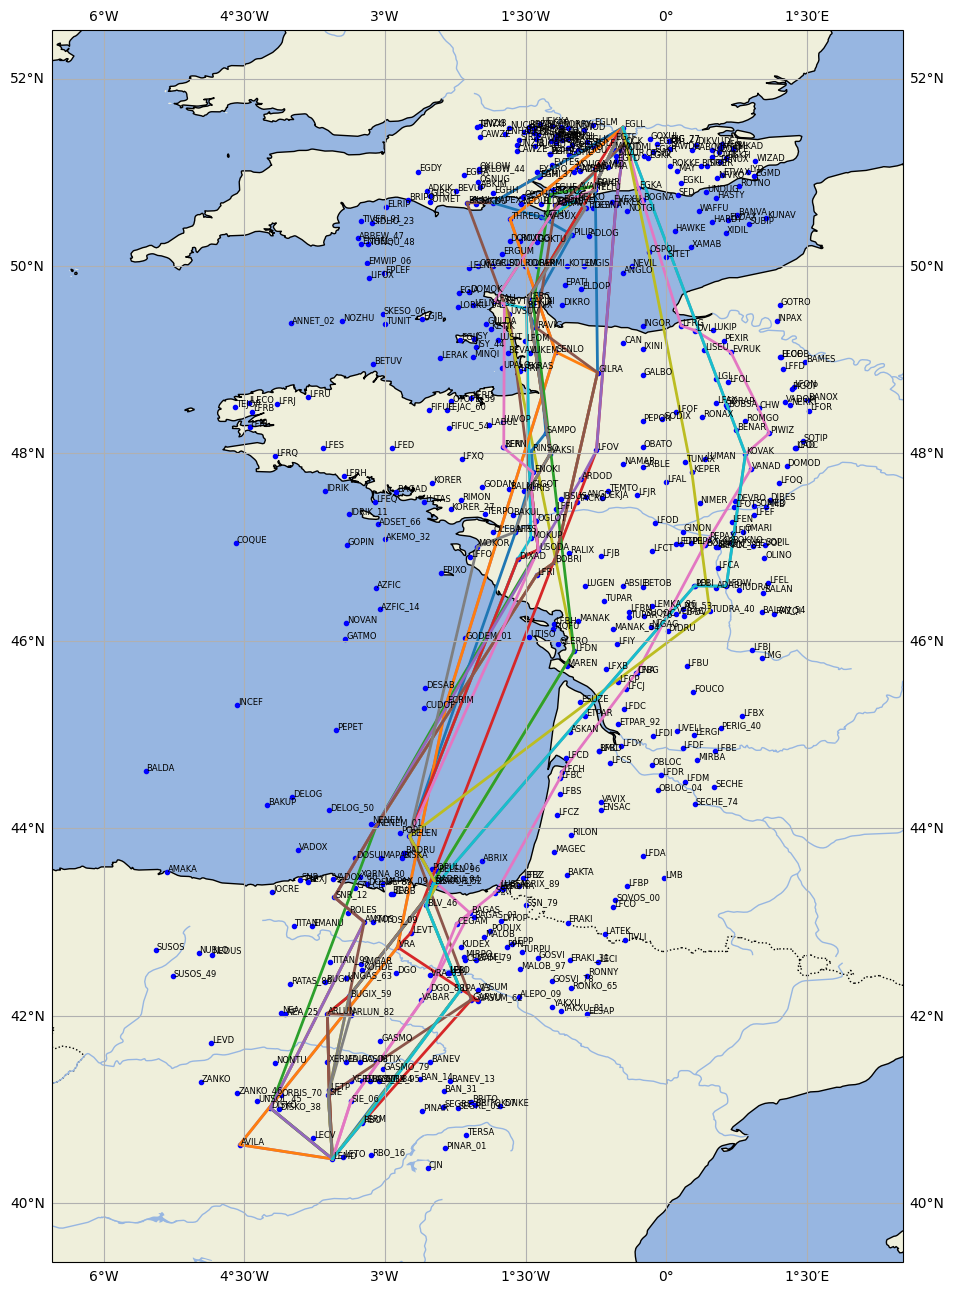

In [21]:
from equinox.helpers.plotters import plot_routes_on_map

plot_routes_on_map(G, routes)
